# Project Goal: Predict Final Exam Score

**Author:** Yekta Ansari 

**Data:** June 2026

## Question: Can I predict a student's final exam score based on their Quiz 1 score?

In [2]:
#Installing scikit-learn 

!pip install scikit-learn

In [1]:
# importing necessary libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Loading my data: 

df = pd.read_csv("C://Users//tuf-w//OneDrive//Documents//Python Data//Simple Linear Regression.csv.csv")

# Checking my data: 
print(df.head())

#Removing all the spaces 
print(df.columns.tolist())
df.columns = df.columns.str.strip()
print(df.columns.tolist())

     Name   Quiz_1  Midterm   Quiz_2  Online_quiz  Final   Attendance 
0    Zahra    20.0      19.5    20.0         18.5   19.50           20
1  Nazanin    20.0      19.5    20.0         18.5   19.50           20
2    Tara     15.0      15.5    15.0         18.0   16.00           15
3    Sara     20.0      20.0    20.0         18.5   19.75           19
4  Fatima     20.0      18.5    20.0         19.0   19.25           20
['Name ', 'Quiz_1', 'Midterm ', 'Quiz_2', 'Online_quiz', 'Final ', 'Attendance ']
['Name', 'Quiz_1', 'Midterm', 'Quiz_2', 'Online_quiz', 'Final', 'Attendance']


In [29]:
# x = Feature(s) we'll use to predict
# y = Target we want to predict
x = df[['Quiz_1']]
y = df['Final']


#80% for training and 20% for testing 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)

print(f'x_train contains {len(x_train)} students')
print(f'x_test contains {len(y_train)} students')

# Creating and training the model
model = LinearRegression()
model.fit(x_train, y_train)


# Getting the equation: y = Θ0 + Θ1*x1
print(f'slope (coeficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')
print(f'\nEquation: Final = {model.intercept_: .2f}+ {model.coef_[0]:.2f} * Quiz_1 ')


# Predicting on test data
y_pred = model.predict(x_test)

# Calculating performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'\n Model Performance:')
print(f' R2 score: {r2:.3f}')
print(f'Mean Squared Error: {mse: .2f}')

# Interpreting R²
if r2 > 0.7: 
    print('Strong relationship. Quiz 1 is a good predictor of Fianl scores')
elif r2 > 0.4: 
    print('Moderate relationship. Quiz 1 somewhat predicts Final scores')
else: 
    print('Weak relationship. Quiz 1 does not predict Final scores')

x_train contains 23 students
x_test contains 23 students
slope (coeficient): 0.78
Intercept: 3.67

Equation: Final =  3.67+ 0.78 * Quiz_1 

 Model Performance:
 R2 score: 0.893
Mean Squared Error:  0.45
Strong relationship. Quiz 1 is a good predictor of Fianl scores


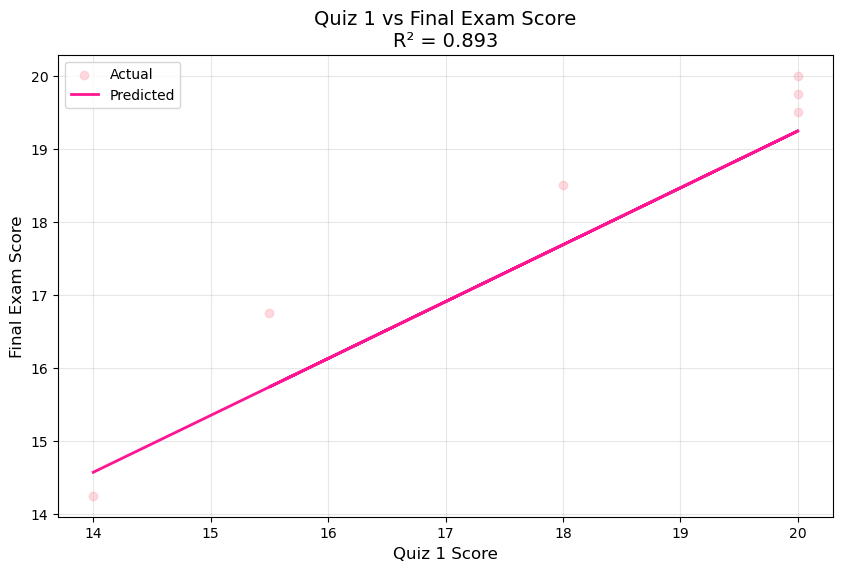

In [34]:
#Creating the plot 
plt.figure(figsize= (10,6))
plt.scatter(x_test, y_test, color='pink', alpha=0.6, label='Actual')
plt.plot(x_test, y_pred, color='deeppink', linewidth=2, label='Predicted')
plt.xlabel('Quiz 1 Score', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)
plt.title(f'Quiz 1 vs Final Exam Score\nR² = {r2:.3f}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
